# Regresión Logística - Clasificación de Sistema Operativo

En esta notebook vamos a predecir qué sistema operativo utiliza un usuario
en base a su comportamiento en un sitio web.

**Características de entrada:**
- `duracion_segundos`: Duración de la visita en segundos
- `paginas_vistas`: Cantidad de páginas vistas durante la sesión
- `cantidad_acciones`: Cantidad de acciones del usuario
- `valor_acciones`: Suma del valor de las acciones

**Etiquetas de salida:**
- `0` → Windows
- `1` → Macintosh
- `2` → Linux

## 1. Importar librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns


In [3]:
from google.colab import files
uploaded = files.upload()  # te abre un explorador para elegir el archivo

Saving usuarios_win_mac_lin.csv to usuarios_win_mac_lin (1).csv


## 2. Cargar y explorar los datos

In [4]:
# Cargamos el dataset
import pandas as pd
df = pd.read_csv('usuarios_win_mac_lin.csv')
print('Shape del dataset:', df.shape)
df.head()

Shape del dataset: (45, 5)


,duracion_segundos,paginas_vistas,cantidad_acciones,valor_acciones,sistema_operativo
0,245,5,12,34,0
1,310,8,20,55,0
2,180,3,8,22,0
3,420,10,25,70,0
4,95,2,5,10,0


In [5]:
# Información general del dataset
print('Forma del dataset:', df.shape)
print('\nInformación general:')
df.info()

Forma del dataset: (45, 5)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   duracion_segundos  45 non-null     int64
 1   paginas_vistas     45 non-null     int64
 2   cantidad_acciones  45 non-null     int64
 3   valor_acciones     45 non-null     int64
 4   sistema_operativo  45 non-null     int64
dtypes: int64(5)
memory usage: 1.9 KB


In [6]:
df.describe()

,duracion_segundos,paginas_vistas,cantidad_acciones,valor_acciones,sistema_operativo
count,45.000000,45.000000,45.000000,45.000000,45.000000
mean,372.111111,8.044444,23.533333,55.666667,1.000000
std,300.564788,6.138387,16.660514,35.510562,0.825723
min,35.000000,1.000000,5.000000,8.000000,0.000000
25%,95.000000,2.000000,11.000000,25.000000,0.000000
50%,290.000000,7.000000,17.000000,48.000000,1.000000
75%,640.000000,13.000000,30.000000,85.000000,2.000000
max,950.000000,20.000000,65.000000,130.000000,2.000000


In [7]:
# Distribución de sistemas operativos
etiquetas = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
conteo = df['sistema_operativo'].value_counts().rename(etiquetas)
print('Distribución de sistemas operativos:')
print(conteo)

Distribución de sistemas operativos:
sistema_operativo
Windows      15
Macintosh    15
Linux        15
Name: count, dtype: int64


## 3. Visualización exploratoria de los datos

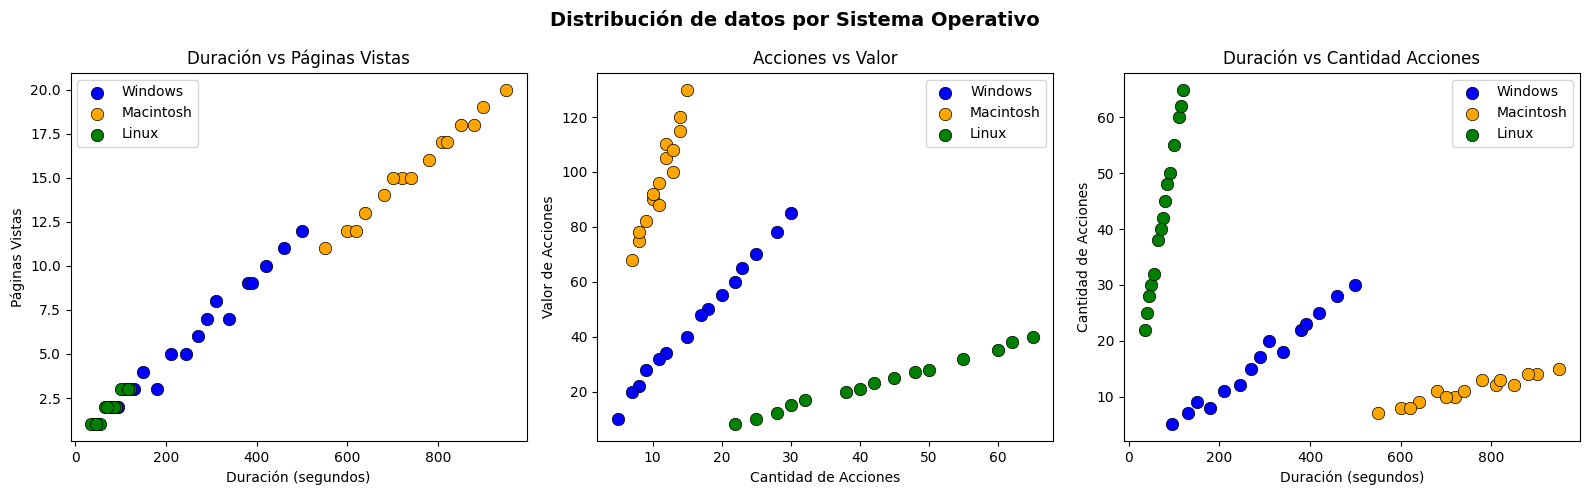

In [8]:
colores = {0: 'blue', 1: 'orange', 2: 'green'}
nombres_so = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de datos por Sistema Operativo', fontsize=14, fontweight='bold')

# Duración vs Páginas Vistas
for so in [0, 1, 2]:
    subset = df[df['sistema_operativo'] == so]
    axes[0].scatter(subset['duracion_segundos'], subset['paginas_vistas'],
                    c=colores[so], label=nombres_so[so], s=80, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Duración (segundos)')
axes[0].set_ylabel('Páginas Vistas')
axes[0].set_title('Duración vs Páginas Vistas')
axes[0].legend()

# Cantidad Acciones vs Valor Acciones
for so in [0, 1, 2]:
    subset = df[df['sistema_operativo'] == so]
    axes[1].scatter(subset['cantidad_acciones'], subset['valor_acciones'],
                    c=colores[so], label=nombres_so[so], s=80, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Cantidad de Acciones')
axes[1].set_ylabel('Valor de Acciones')
axes[1].set_title('Acciones vs Valor')
axes[1].legend()

# Duración vs Cantidad Acciones
for so in [0, 1, 2]:
    subset = df[df['sistema_operativo'] == so]
    axes[2].scatter(subset['duracion_segundos'], subset['cantidad_acciones'],
                    c=colores[so], label=nombres_so[so], s=80, edgecolors='black', linewidth=0.5)
axes[2].set_xlabel('Duración (segundos)')
axes[2].set_ylabel('Cantidad de Acciones')
axes[2].set_title('Duración vs Cantidad Acciones')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. Preparar los datos para el modelo

In [9]:
# Separamos las características (X) de las etiquetas (Y)
X = df[['duracion_segundos', 'paginas_vistas', 'cantidad_acciones', 'valor_acciones']].values
Y = df['sistema_operativo'].values

print('\nPrimeros 5 valores de X:')
print(X[:5])
print('\nPrimeros 5 valores de Y:')
print(Y[:5])


Primeros 5 valores de X:
[[245   5  12  34]
 [310   8  20  55]
 [180   3   8  22]
 [420  10  25  70]
 [ 95   2   5  10]]

Primeros 5 valores de Y:
[0 0 0 0 0]


In [10]:
# Dividimos en datos de entrenamiento (80%) y de prueba (20%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print('Datos de entrenamiento:', X_train.shape)
print('Datos de prueba:       ', X_test.shape)

Datos de entrenamiento: (36, 4)
Datos de prueba:        (9, 4)


## 5. Crear y entrenar el modelo

In [12]:
# Creamos el clasificador de Regresión Logística
clasificador = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
clasificador.fit(X_train, Y_train)

print('Modelo entrenado correctamente ✓')

Modelo entrenado correctamente ✓


## 6. Evaluación del modelo

In [13]:
# Predicción sobre los datos de prueba
Y_pred = clasificador.predict(X_test)

print('Valores reales:    ', Y_test)
print('Valores predichos: ', Y_pred)

Valores reales:     [2 1 1 2 2 2 0 0 0]
Valores predichos:  [2 1 1 2 2 2 2 0 0]


In [14]:
# Accuracy (precisión global)
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy del modelo: {accuracy * 100:.2f}%')

Accuracy del modelo: 88.89%


## 7. Predicción de nuevos usuarios

In [17]:
# Definimos nuevos usuarios con sus características
nuevos_usuarios = np.array([
    [300, 7, 18, 52],   # Usuario A
    [750, 16, 11, 98],  # Usuario B
    [60,  2,  40, 22],  # Usuario C
])

# Realizamos la predicción
predicciones = clasificador.predict(nuevos_usuarios)
probabilidades = clasificador.predict_proba(nuevos_usuarios)

print('Predicciones para nuevos usuarios:')
print('=' * 55)
for i, (pred, proba) in enumerate(zip(predicciones, probabilidades)):
    so = nombres_so[pred]
    print(f'\nUsuario {chr(65+i)}: {nuevos_usuarios[i]}')
    print(f'  → Sistema Operativo predicho: {so} ({pred})')
    print(f'  → Probabilidades: Windows={proba[0]:.2%} | Mac={proba[1]:.2%} | Linux={proba[2]:.2%}')

Predicciones para nuevos usuarios:

Usuario A: [300   7  18  52]
  → Sistema Operativo predicho: Windows (0)
  → Probabilidades: Windows=100.00% | Mac=0.00% | Linux=0.00%

Usuario B: [750  16  11  98]
  → Sistema Operativo predicho: Macintosh (1)
  → Probabilidades: Windows=0.00% | Mac=100.00% | Linux=0.00%

Usuario C: [60  2 40 22]
  → Sistema Operativo predicho: Linux (2)
  → Probabilidades: Windows=0.00% | Mac=0.00% | Linux=100.00%


## 8. Visualización de la zona de decisión (2 características)

Como solo podemos graficar en 2D, usamos las dos características más representativas: **duración** y **páginas vistas**

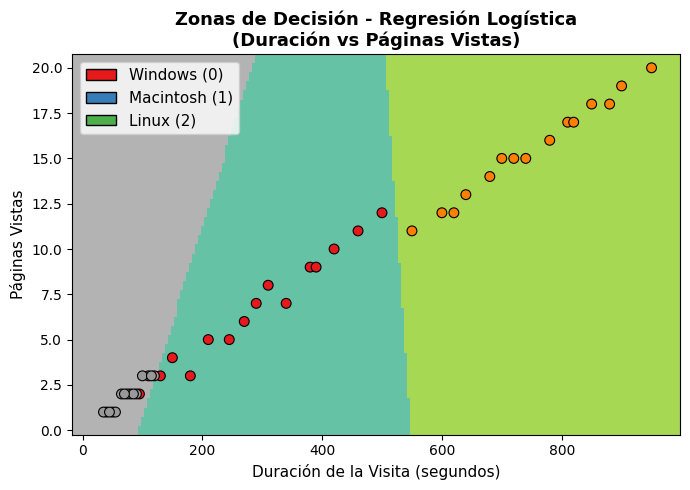

El fondo de color muestra qué SO predice el modelo para cada zona del gráfico.


In [31]:
# Entrenamos un modelo auxiliar solo con 2 características para poder graficar
X_2d = df[['duracion_segundos', 'paginas_vistas']].values
Y_2d = df['sistema_operativo'].values

clasificador_2d = LogisticRegression(max_iter=1000, random_state=42)
clasificador_2d.fit(X_2d, Y_2d)
# Definimos el rango del gráfico
x_min, x_max = X_2d[:, 0].min() - 50, X_2d[:, 0].max() + 50
y_min, y_max = X_2d[:, 1].min() - 1,  X_2d[:, 1].max() + 1

# Creamos la malla de puntos
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 5),
    np.arange(y_min, y_max, 0.5)
)

# Predecimos el SO para cada punto de la malla
malla = clasificador_2d.predict(np.c_[xx.ravel(), yy.ravel()])
malla = malla.reshape(xx.shape)

# Graficamos
plt.figure(figsize=(7, 5))
plt.pcolormesh(xx, yy, malla, cmap=plt.cm.Set2, shading='auto')

# Puntos reales
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=Y_2d,
                     cmap=plt.cm.Set1, s=50,
                     edgecolors='black', linewidth=0.8)

# Leyenda
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='#E41A1C', edgecolor='black', label='Windows (0)'),
    Patch(facecolor='#377EB8', edgecolor='black', label='Macintosh (1)'),
    Patch(facecolor='#4DAF4A', edgecolor='black', label='Linux (2)'),
]
plt.legend(handles=leyenda, loc='upper left', fontsize=11)

plt.title('Zonas de Decisión - Regresión Logística\n(Duración vs Páginas Vistas)',
          fontsize=13, fontweight='bold')
plt.xlabel('Duración de la Visita (segundos)', fontsize=11)
plt.ylabel('Páginas Vistas', fontsize=11)
plt.tight_layout()
plt.show()

print('El fondo de color muestra qué SO predice el modelo para cada zona del gráfico.')


## Conclusiones

- El modelo de **Regresión Logística** aprendió a distinguir entre los tres sistemas operativos en base al comportamiento del usuario en el sitio web.
- **Windows**: sesiones de duración media, páginas moderadas, acciones intermedias.
- **Macintosh**: sesiones largas, muchas páginas vistas, pocas acciones pero de alto valor.
- **Linux**: sesiones cortas, pocas páginas, pero gran cantidad de acciones rápidas.
- La **zona de decisión** muestra visualmente cómo el modelo separa las regiones del espacio de datos.